In [24]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import scipy.special as sp
from files.genpulse import genpulse
from files.rosenmodel import rosenmodel
from IPython.display import Audio      # βιβιοθήκη για να "παίζουμε" ήχους (μεταξύ άλλων)

## Άσκηση - Σύνθεση φωνής από υπολογιστή
Σε αυτήν την άσκηση θα προσπαθήσουμε να συνθέσουμε έμφωνους ήχους (/α/, /ε/, /ο/) με όσα γνωρίζουμε από το μετασχ. Ζ και όσα επιπλέον μάθουμε σε αυτό το εργαστήριο σχετικά με την παραγωγή φωνής. Ο τρόπος που θα ακολουθήσουμε είναι ιδιαίτερα παλαιός και απλός, γι' αυτό και όχι τόσο αποδοτικός. Παρ' όλα αυτά, οι πρώτες τεχνικές σύνθεσης φωνής βασίζονταν σε τέτοια μοντέλα και προσεγγίσεις. Για μια σύγκριση προσεγγίσεων σύνθεσης φωνής ανά τα χρόνια, μπορείτε να ακούσετε εδώ μερικά δείγματα (και στα ελληνικά!): http://speech.ilsp.gr/synthesis/samples. Η πρώτη μέθοδος (formant synthesis) ουσιαστικά ακολουθεί ό,τι θα κάνουμε στο εργαστήριο αυτό.
Ένα απλό μοντέλο παραγωγής ανθρώπινης φωνής για όλων των ειδών τους ήχους φαίνεται στο Σχήμα 1. Στο εργαστήριο αυτό, θα μας απασχολήσουν αποκλειστικά οι έμφωνοι ήχοι. Έχουμε αριθμήσει τα συστήματα Σ1, Σ2, και Σ3 που εμπλέκονται στην παραγωγή έμφωνων ήχων. Ας μιλήσουμε λίγο για αυτά.

<center>
<div>
<img src="./files/sourcefilter.png" width="1000" />
</div>
Σχήμα 1 : Απλό μοντέλο παραγωγής ανθρώπινης φωνής για έμφωνους, άφωνους, και κλειστούς ήχους.
</center>

* **Είσοδος:** Θεωρητικά, οι έμφωνοι ήχοι μοντελοποιούνται ως περιοδικά σήματα για όσο διαρκούν. Ας θεωρήσουμε ότι η συχνότητα δειγματοληψίας με την οποία θα παράξουμε το σήμα μας είναι $f_s = 8000$ Hz. Γνωρίζουμε ότι η ανδρική φωνή έχει θεμελιώδη συχνότητα $100$ Hz κατά μέσο όρο, ενώ η γυναικεία έχει θεμελιώδη συχνότητα $200$ Hz κατά μέσο όρο. Αυτό σημαίνει ότι οι φωνητικές χορδές πάλλονται $100$ φορές το δευτερόλεπτο στους άνδρες και $200$ φορές το δευτερόλεπτο στις γυναίκες, κατά μέσο όρο (στα παιδιά ακόμα περισσότερες φορές). Επίσης, σημαίνει ότι οι αποστάσεις μεταξύ των ``παλμών'' (που μοντελοποιούνται με συναρτήσεις Δέλτα) του σήματος εισόδου στο Σχήμα 1 θα είναι $T_0 = 1/100$ s στους άνδρες και $T_0 = 1/200$ s στις γυναίκες.\
Με τη δεδομένη συχνότητα δειγματοληψίας $f_s$, τα παραπάνω αντιστοιχούν σε περιόδους διάρκειας $P=80$ και $P=40$ δειγμάτων στο χρόνο, για ανδρική και γυναικεία φωνή αντίστοιχα, σε μια περίοδο. Αυτό σημαίνει ότι μια βασική περίοδος ενός έμφωνου σήματος στο χρόνο επαναλαμβάνεται κάθε $80$ ή $40$ δείγματα. Η διαφορά αυτή οφείλεται στο μέγεθος των φωνητικών χορδών: οι άνδρες έχουν μεγαλύτερες φωνητικές χορδές από τις γυναίκες.

* **Σύστημα Σ1:** Σύμφωνα με το μοντέλο που φαίνεται στο Σχήμα 1, η φωνή παράγεται - θεωρητικά - όταν μια σειρά από συναρτήσεις Δέλτα, που απέχουν μεταξύ τους απόσταση (περίοδο) $P$ δείγματα,

$$e[n] = \sum_{k=-\infty}^{+\infty}\delta[n-kP], \: \: \: k \in Z$$

παρουσιαστεί ως είσοδος σε ένα ΓΧΑ σύστημα με κρουστική απόκριση $g[n]$ (και με συνάρτηση μεταφοράς $G(z)$) της μορφής

$$g[n] =
\left\{
\begin{array}{lr}
        \frac{1}{2}\Big(1-\cos\Big(\frac{\pi n}{N_1}\Big)\Big), & 0 \leq n \leq N_1\\
        \displaystyle \cos\Big(\frac{\pi(n-N_1)}{2N_2}\Big), & N_1 \leq n \leq N_1 + N_2\\
        0, & \text{αλλού}
\end{array}
\right.$$

Το ΓΧΑ σύστημα $g[n]$ αντιστοιχεί σε μια περίοδο του σήματος που παρουσιάζεται ακριβώς επάνω από τις φωνητικές σας χορδές. Το σύστημα $g[n]$ ονομάζεται μοντέλο του Rosenberg, και ήταν από τα πρώτα μοντέλα που προσπάθησαν να περιγράψουν μια περίοδο του σήματος που παράγεται ακριβώς επάνω από τις φωνητικές μας χορδές. Για την ακρίβεια, το μοντέλο αυτό περιγράφει την ταχύτητα ροής αέρα ακριβώς επάνω από τις φωνητικές μας χορδές.
Γνωρίζουμε από τη θεωρία ότι η έξοδος του συστήματος $g[n]$ με είσοδο το σήμα $e[n]$ θα είναι η συνέλιξη των δυο σημάτων, που καταλήγει να είναι η επανάληψη του $g[n]$ ανά $kP$ δείγματα. Αυτό μας δημιουργεί πολλές περιόδους του $g[n]$, ώστε να μπορούμε να ακούσουμε το παραγόμενο φώνημα στο τέλος της διαδικασίας (μια μόνο περίοδος του $g[n]$ είναι πολύ μικρή σε διάρκεια για να μπορεί να ακουστεί).

* **Σύστημα Σ2:** Το παραπάνω σήμα πρέπει να περάσει από ένα δεύτερο ΓΧΑ σύστημα που μοντελοποιεί τη φωνητική οδό (φάρυγγας και στοματική κοιλότητα). Η φωνητική οδός συμβολίζεται με το σύστημα $V(z)$ στο Σχήμα 1 και διαμορφώνει κατάλληλα τον ήχο (ανάλογα με ποιό φώνημα θέλουμε να προφέρουμε). Θα προσπαθήσουμε να φτιάξουμε συστήματα που περιγράφουν τη φωνητική οδό, με τρόπο που θα δείτε παρακάτω.

* **Σύστημα Σ3** Τέλος, η έξοδος από αυτό το ΓΧΑ σύστημα παρουσιάζεται ως είσοδος σε ένα τρίτο ΓΧΑ σύστημα, που μοντελοποιεί την επίδραση που έχουν τα χείλη μας στο σήμα που φτάνει σε αυτά. Το τελευταίο αυτό σύστημα έχει συνάρτηση μεταφοράς
$$R(z) = 1 - 0.95z^{-1}$$
Ουσιαστικά, η επίδραση αυτή μετατρέπει το σήμα από σήμα μεταβολής ταχύτητας σε σήμα μεταβολής πίεσης. Η έξοδος από αυτό το σύστημα είναι το τελικό σήμα φωνής.

Όπως καταλαβαίνετε από τα παραπάνω, αυτό που αλλάζει όταν προφέρουμε διαφορετικά φωνήματα (/α/, /ε/, /ο/) είναι κυρίως η φωνητική οδός, ο τρόπος που τοποθετούμε το στόμα μας, δηλαδή το σύστημα $V(z)$. Όλα τα υπόλοιπα παραμένουν σχεδόν ίδια. Για παράδειγμα, όταν θέλουμε να προφέρουμε το φώνημα /α/, η απόκριση πλάτους του συστήματος που περιγράφει την φωνητική οδό, δηλ. το $|V(e^{j\omega})|$, είναι κατά μέσο όρο όπως στο Σχήμα 2, σε λογαριθμική κλίμακα (για το αγγλικό /α/). Όμοια στα δυο πιο κάτω Σχήματα 3,4, η λογαριθμική απόκριση πλάτους των /ε/ και /ο/.
Γνωρίζετε ότι αν τοποθετήσετε πόλους σε κατάλληλα σημεία στο μιγαδικό επίπεδο, μπορείτε να δημιουργήσετε τοπικά μέγιστα στην απόκριση πλάτους ενός συστήματος.

Χρησιμοποιώντας τις παραπάνω πληροφορίες, προσπαθήστε να συνθέσετε τους ήχους /α/, /ε/, /ο/. Χρησιμοποιήστε ανδρική ή γυναικεία φωνή (ό,τι θέλετε), επιλέγοντας κατάλληλο $f_0$ για το σήμα $e[n]$ που θα φτιάξετε - σημειώστε ότι λόγω διαφορετικού μεγέθους φωνητικής οδού, οι συχνότητες όπου εμφανίζονται τα τοπικά μέγιστα στα γυνακεία φωνήματα είναι λίγο διαφορετικές, αλλά για τους σκοπούς του εργαστηρίου, θεωρήστε ότι τα Σχήματα 2,3,4 αφορούν και τα δυο φύλα.

Στην προσπάθειά σας αυτή, σας δίνουμε μερικές έτοιμες συναρτήσεις που **δε χρειάζεται να πειράξετε**, παρά μόνο να καλέσετε. Οι συναρτήσεις αυτές είναι:

* genpulse.py: η συνάρτηση αυτή παράγει το αρχικό σήμα εισόδου $e[n]$ για έμφωνους ήχους. Για παράδειγμα, αν θέλετε να παράξετε ένα σήμα $e[n]$ διάρκειας $t$ δευτερολέπτων και θεμελιώδους συχνότητας $f_0$ Hz, τότε πρέπει να την καλέσετε ως:
<code>
e = genpulse(f0, t)
</code>

* rosenmodel.m: η συνάρτηση αυτή δημιουργεί την κρουστική απόκριση $g[n]$, δηλ. το μοντέλο του Rosenberg, για το σύστημα Σ1 του Σχήματος 1. Για παράδειγμα, αν η θεμελιώδης συχνότητα που θέλετε να συνθέσετε είναι $100$ Hz, δηλ. $80$ δείγματα ανά περίοδο, και θέλετε το $N_1$ να είναι $60$ δείγματα, και το $N_2$ να είναι $10$ δείγματα, τότε θα την καλέσετε ως
<code>
g = rosenmodel(60,10,100)
</code>

Λόγω κατασκευής του μοντέλου, πρέπει το άθροισμα $N_1+N_2$ να είναι λιγότερο από $f_s/f_0$, αλλιώς η συνάρτηση σας επιστρέφει σφάλμα, και πρέπει να ορίσετε ξανά τις τιμές ώστε να ικσνοποιείται η συνθήκη. Ο ``κανόνας '' είναι ότι το $N_1$ πρέπει να είναι αρκετά μεγαλύτερο από το $N_2$, για λόγους που δεν αναλύονται εδώ. Ασφαλώς η επιλογή των τιμών $N_1$ και $N_2$ επηρεάζει το αποτέλεσμα, αλλά αυτό είναι δευτερεύουσα παράμετρος σε αυτό το εργαστήριο.

Για όλα τα παραπάνω, ακολουθήστε τα παρακάτω βήματα:

In [25]:
# Σύνθεση φωνήεντος με χρήση του πεδίου του Ζ

# Συχνότητα δειγματοληψίας
fs = 8000

(γ') Επιλέξτε μια θεμελιώδη συχνότητα $f_0$ για το σήμα $e[n]$. Αποθηκεύστε την επιλογή σας στη μεταβλητή f0. Ουσιαστικά, με αυτό διαλέγετε αν θα παράξετε ανδρική ή γυναικεία φωνή. Αποδεκτά ορίσματα για ανδρική φωνή ανήκουν στο εύρος $[80, 140]$ Hz, ενώ για γυναικεία φωνή στο εύρος $[160, 280]$ Hz.

In [26]:
######################################################################################
# Δημιουργία του σήματος διέγερσης - μια σειρά γλωττιδικών παλμών που 
# θα περάσουν μέσα από τη φωνητική οδό
######################################################################################

# Επιλογή θεμελιώδους συχνότητας f0
f0 = 100 # ανδρική φωνή

(δ') Καλέστε τη συνάρτηση genpulse με κατάλληλα ορίσματα, για να φτιάξετε το σήμα $e[n]$, και αποθηκεύστε την έξοδό της στο διάνυσμα e. Φροντίστε να επιλέξετε λίγα δευτερόλεπτα ώστε να μπορείτε να ακούσετε στο τέλος το σήμα που θα συνθέσετε (π.χ. επιλέξτε $t=2$ ως όρισμα της genpulse).

In [27]:
# Κλήση του genpulse.py για δημιουργία μιας σειράς δέλτα - αποθηκεύστε το αποτέλεσμα στο διάνυσμα e
t = 2
e = genpulse(f0, t)
# εκτύπωση του e
# Αφαιρέστε τον σχολιασμό από τις 2 παρακάτω γραμμές αν θέλετε το τελικό σήμα σας να είναι πιο "φυσικό"
# προσθέτοντας λίγο τυχαίο θόρυβο χαμηλής ισχύος στο διάνυσμα e
#P = 0.0125
#e = e + P*np.random.randn(1, len(e))[0]
# εκτύπωση του e

(ε') Καλέστε τη συνάρτηση rosenmodel για να συνθέσετε μια περίοδο του σήματος $g[n]$, με τιμές $N_1, N_2$ της επιλογής σας (προσέξτε να ανταποκρίνονται στις προδιαγραφές που συζητήθηκαν νωρίτερα). Αποθηκεύστε την έξοδό της στο διάνυσμα g. Σχεδιάστε το με την εντολή plt.plot για να δείτε πως μοιάζει. Αυτό που θα δείτε είναι μια περίοδος του σήματος που παράγεται επάνω από τις φωνητικές σας χορδές όταν παράγετε έμφωνους ήχους!

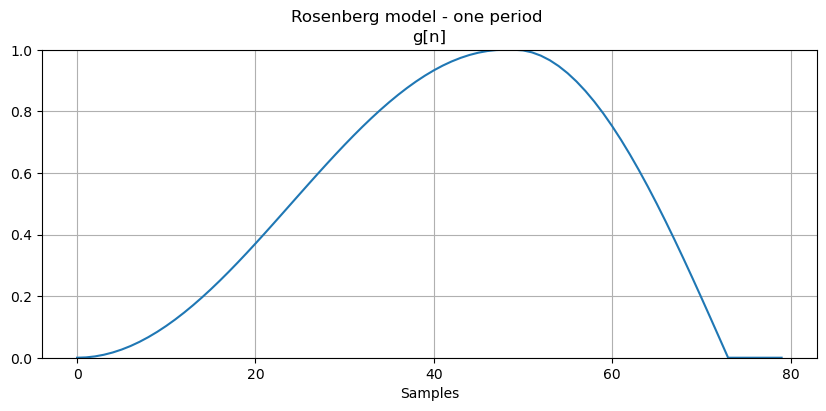

In [28]:
# Κλήση του rosenmodel.py για δημιουργία μιας περιόδου γλωττιδικού παλμού - αποθηκεύστε την στο διάνυσμα g
g = rosenmodel(round(0.6*fs/f0), round(0.3*fs/f0), f0)
# εκτύπωση του g

plt.figure(figsize=(10,4))
plt.suptitle('Rosenberg model - one period')
plt.plot(g.T)
plt.grid(True)
plt.xlabel('Samples')
plt.title('g[n]')
plt.ylim(0.0, 1.0)
plt.xticks([0, 20, 40, 60, 80])
plt.show()

(στ') Το Σχήμα 1 δείχνει ότι το σήμα $e[n]$ μπαίνει ως είσοδος στο σύστημα με κρουστική απόκριση $g[n]$. Γνωρίζετε ότι η έξοδος ενός τέτοιου συστήματος δίνεται ως η συνέλιξη της εισόδου με την κρουστική απόκριση. Χρησιμοποιήστε τη συνάρτηση np.conv για να βρείτε την έξοδο, και αποθηκεύστε τη στο διάνυσμα gp.

In [29]:
# Συνελίξτε τα e και g για να δημιουργήσετε μια σειρά γλωττιδικών παλμών
# Αποθηκεύστε το αποτέλεσμα στο διάνυσμα gp
gp = sig.convolve(e.reshape(1, len(e)), g)[0]

(ζ') Σχεδιάστε με την εντολή plt.plot το αποτέλεσμα gp. Όταν προφέρετε σταθερά έναν έμφωνο ήχο (όπως όταν κάνετε /ααααα/ στο γιατρό για να εξετάσει τις αμυγδαλές σας), τοτε αυτό το σήμα παράγεται ακριβώς επάνω από τις φωνητικές σας χορδές!

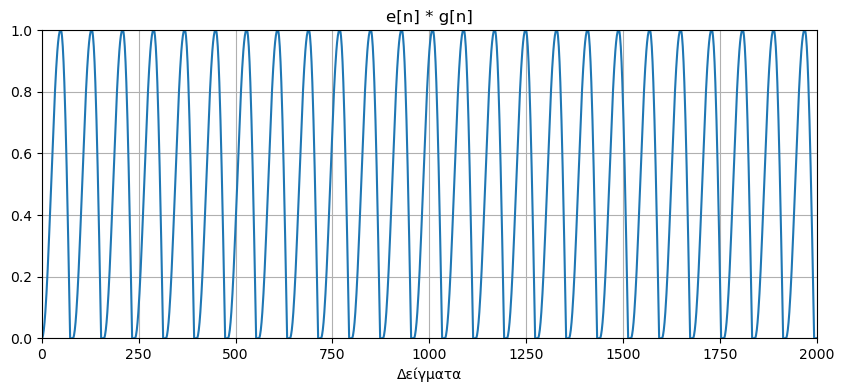

In [39]:
plt.figure(figsize=(10,4))
plt.plot(gp)
plt.grid()
plt.xlabel('Δείγματα')
plt.title('e[n] * g[n]')
plt.xlim(0, 2000)
plt.ylim(0.0, 1.0)
plt.show()

(η') Για να παράξετε το φίλτρο $V(z)$ για ένα συγκεκριμένο φώνημα, πρέπει να συμβουλευτείτε την αντίστοιχη απόκριση πλάτους του Σχήματος 2. Για παράδειγμα, το /α/ φαίνεται να έχει υψηλές τιμές στις συχνότητες $F_i = 700, 1100, 2500$ και $3600$ Hz. Αυτές τις υψηλές τιμές φάσματος πλάτους θα τις δημιουργήσετε με χρήση πόλων οι οποίοι θα βρίσκονται στις κατάλληλες θέσεις (γωνίες και ακτίνες) στο z-επίπεδο, δηλ. το σύστημα $V(z)$ θα είναι της μορφής

$$V(z) = \frac{1}{\prod_{k=1}^M (1 -z_k z^{-1})(1 - z_k^* z^{-1})}$$

με $M$ ο αριθμός των πόλων στο διάστημα $[0,\pi]$ (δηλ. το πλήθος των κορυφών στις αποκρίσεις πλάτους των σχημάτων που σας δίνονται). Προφανώς, εσείς θα εκτιμήσετε το $V(z)$ επάνω στο μοναδιαίο κύκλο, δηλ. σας ενδιαφέρει ο μετασχ. Fourier του (η απόκριση πλάτους του συστήματος). Αυτό θα γίνει τοποθετώντας κατάλληλα τους πόλους στο μιγαδικό επίπεδο ώστε να ``κατασκευάσετε'' την απόκριση πλάτους που σας δίνεται για κάθε φώνημα.

Ακολουθήστε το παρακάτω παράδειγμα για το φώνημα /α/, για να καταλάβετε περισσότερα:
* <u>Βήμα 1:</u>
    * Η πρώτη συχνότητα που το /α/ παρουσιάζει υψηλή τιμή στο φάσμα πλάτους είναι η $F_1 = 700$ Hz. Η συχνότητα αυτή αντιστοιχεί σε $\Omega_1 = 2\pi F_1/f_s$ rad/sample στο διάστημα $[0, \pi]$. Αποθηκεύστε τη στη μεταβλητή Omega_1.
    * Η υψηλή τιμή του φάσματος πλάτους του /α/ σε αυτή τη συχνότητα $\Omega_1$ σημαίνει ότι στη γωνία $\omega = \Omega_1$ του z-επιπέδου, υπάρχει ένας πόλος $z_1$. Ο πόλος αυτός θα είναι της μορφής
        <code>
          z1 = a_1 * np.exp(1i * Omega_1)
        </code>

        με $a_1$ το μέτρο του πόλου (δηλ. η απόσταση από το κέντρο των αξόνων). Βάλτε μια τιμή του $a_1$ κοντά στο $0.98$. Όμως, επειδή το $V(z)$ ανταποκρίνεται σε πραγματική συνάρτηση $v[n]$, θα πρέπει να έχει για κάθε πόλο $z$ στο $[0, \pi)$, και έναν συζυγή του, $z^*$, στο $[\pi, 2\pi)$. Ο συζυγής ενός μιγαδικού βρίσκεται εύκολα με τη συνάρτηση ``np.conj``. Για τον παραπάνω πόλο, θα είναι
        <code>
            z1c = z1.conj()
        </code>
    * Αυτοί οι δυο πόλοι λοιπόν συνεισφέρουν στο $V(z)$ έναν όρο της μορφής
        $\begin{equation}
            \frac{1}{(1 - z_1z^{-1})(1 - z_1^ * z^{-1})}
        \end{equation}$
        Ο πολλαπλασιασμός των δυο αυτών πολυωνύμων πρώτης τάξης του παρονομαστή επιτυγχάνεται με τη συνάρτηση np.conv ως

        <code>
            oros1 = np.real(sig.convolve(np.hstack([1, -z_a1]), np.hstack([1, -z_a1c])))
        </code>

        Το διάνυσμα ``oros1`` περιέχει τους συντελεστές του πολυωνύμου του $z^{-1}$ που προκύπτει από το γινόμενο του παρονομαστή της Σχέσης (9).

In [31]:
#####################################################################
# Δημιουργία του φίλτρου V(z) για τη φωνητική οδό - 
# είναι φίλτρο μόνο με πόλους (χωρίς μηδενικά στο επίπεδο)
#####################################################################

# 1ο ζεύγος πόλων
###################
Omega_a1 = 2 * np.pi * 700 / fs
a_1 = 0.982
z_a1 = a_1 * np.exp(1j * Omega_a1)
z_a1c = z_a1.conj()
oros_a1 = np.real(sig.convolve(np.hstack([1, -z_a1]), np.hstack([1, -z_a1c])))


   * <u>Βήμα 2:</u>
      * Δημιουργήστε γινόμενα πολυωνύμων όπως παραπάνω για κάθε συχνότητα $F_i$ που βλέπετε να έχει υψηλή τιμή στο φάσμα πλάτους του /α/. Αποθηκεύστε τους συντελεστές τους στα διανύσματα

          <code>
            oros1, oros2, oros3, oros4
          </code>

          όπως ακριβώς κάναμε παραπάνω. Εύκολα μπορείτε να βρείτε τις γωνίες $\Omega_i$ των πόλων. Όμως για τα μέτρα τους, $a_i$, επιλέξτε αρχικά τυχαίες τιμές μεταξύ $0.85$ και $0.95$.
      * Όταν κάνετε τα παραπάνω για όλες τις συχνότητες, πολλαπλασιάστε όλους τους όρους αυτούς μεταξύ τους με τη συνάρτηση conv ως
          <code>
            oroi12 = np.conv(oros1, oros2)
            oroi34 = np.conv(oros3, oros4)
            den = np.conv(oroi12, oroi34)
            num = 1
          </code>
          για να δημιουργήσετε το τελικό πολυώνυμο του παρονομαστή του $V(z)$ στη μεταβλητή-διάνυσμα den.
      * Ελέγξτε το φάσμα πλάτους που φτιάξατε σε λογαριθμική κλίμακα ώσε να μπορείτε να το συγκρίνετε με τα σχήματα που σας δίνονται, χρησιμοποιώντας τις παρακάτω γραμμές
          <code>
            W, V = sig.freqz(num, den, 1024, fs)
            plt.plot(W, 20*log10(abs(V)))
            plt.grid(True)
          </code>
      * Η πρώτη σας απόπειρα μάλλον δε θα μοιάζει τόσο με το φάσμα πλάτους που βλέπετε στο Σχήμα 3. Θα χρειαστεί να πειραματιστείτε αρκετά, καθώς η εισαγωγή ενός νέου πόλου κάθε φορά θα επηρεάζει και τις υπόλοιπες συχνότητες. Πειραματιστείτε με τις τιμές του μέτρου a $_i$ του κάθε πόλου για να επιτύχετε τιμές φάσματος πλάτους στις συχνότητες $F_i$ όπως στο Σχήμα 3. Ελέγξτε κάθε φορά το αποτέλεσμά σας όπως παραπάνω. Ως hint για το φώνημα /α/, σας δίνεται η Εικόνα του Σχήματος 2 που περιγράφει σχηματικά πως θα τοποθετήσετε τους πόλους στο μιγαδικό επίπεδο και πως αυτοί θα επηρεάσουν την απόκριση πλάτους $|V(e^{j\omega})|$ - μη σας απασχολεί η απόκριση φάσης. Προσέξτε ότι οι πόλοι στο διάστημα $(-\pi, 0)$ (ή $(\pi, 2\pi)$) είναι οι συζυγείς των υπολοίπων.
<center>
<div>
<img src="./files/DSPhint4.png" width="1000" />
</div>
Σχήμα 2 : Hint..
</center>

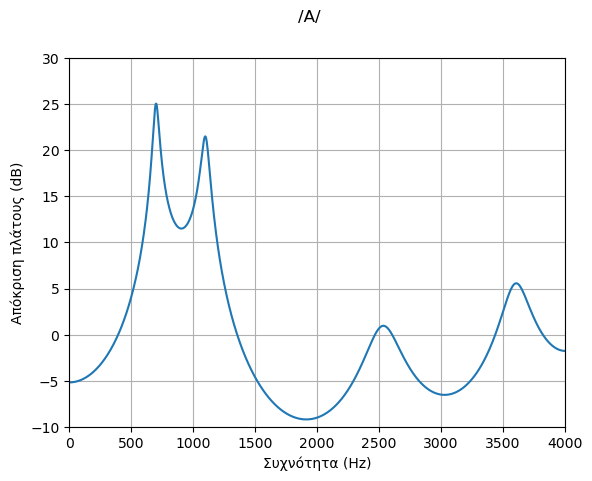

In [32]:
# 2ο ζεύγος πόλων
###################
Omega_a2 = 2 * np.pi * 1100 / fs
a_2 = 0.975
z_a2 = a_2 * np.exp(1j * Omega_a2)
z_a2c = z_a2.conj()
oros_a2 = np.real(sig.convolve(np.hstack([1, -z_a2]), np.hstack([1, -z_a2c])))

# 3ο ζεύγος πόλων
###################
Omega_a3 = 2 * np.pi * 2530 / fs
a_3 = 0.9
z_a3 = a_3 * np.exp(1j * Omega_a3)
z_a3c = z_a3.conj()
oros_a3 = np.real(sig.convolve(np.hstack([1, -z_a3]), np.hstack([1, -z_a3c])))

# 4ο ζεύγος πόλων
###################
Omega_a4 = 2 * np.pi * 3600 / fs
a_4 = 0.92
z_a4 = a_4 * np.exp(1j * Omega_a4)
z_a4c = z_a4.conj()
oros_a4 = np.real(sig.convolve(np.hstack([1, -z_a4]), np.hstack([1, -z_a4c])))

# Συνδυάστε τους πόλους για να σχηματίσετε το πολυώνυμο V(z) - χρησιμοποιήστε τη συνάρτηση conv
oroi_a12 = sig.convolve(oros_a1, oros_a2)
oroi_a34 = sig.convolve(oros_a3, oros_a4)
dena = sig.convolve(oroi_a12, oroi_a34)
numa = 1

# Έλεγχος - πειραματιστείτε με τα a_i
W, Va = sig.freqz(numa, dena, worN=1024, fs=fs)
fig = plt.figure()
plt.plot(W, 20 * np.log10(abs(Va)))
plt.grid(True)
plt.suptitle('/A/')
plt.xlabel('Συχνότητα (Hz)')
plt.ylabel('Απόκριση πλάτους (dB)')
plt.xlim(0, 4000)
plt.ylim(-10, 30)
plt.show()

* <u>Βήμα 3:</u>
    * Όταν έχετε μια καλή προσέγγιση του φάσματος πλάτους που σας δίνεται, βρείτε την έξοδο του συστήματος $V(z)$ για είσοδο το σήμα gp που έχετε φτιάξει αρχικά. Η συνάρτηση np.conv δε μας είναι βολική γιατί το $V(z)$ είναι στο χώρο του Ζ ενώ το gp είναι στο χώρο του χρόνου. Χρησιμοποιήστε τη συνάρτηση np.filter, ως
      <code>
          y = np.filter(num, den, gp)
      </code>

In [33]:
######################################################################################################
# Περάστε τη σειρά γλωττιδικών παλμών gp μέσα από το σύστημα V(z) - χρησιμοποιήστε τη συνάρτηση filter
######################################################################################################
numa = np.array(numa, dtype=np.float64).flatten()
dena = np.array(dena, dtype=np.float64)
gp = np.array(gp, dtype=np.float64).flatten()

y = sig.lfilter(numa, dena, gp)

(θ') Για να παράξετε το τελικό συνθετικό σήμα φωνής, περάστε την έξοδο y που μόλις βρήκατε ως είσοδο στο σύστημα $R(z)$. Μπορείτε να βρείτε εύκολα το $r[n]$ στο χαρτί σας, οπότε μπορείτε να χρησιμοποιήσετε είτε τη συνάρτηση np.conv, είτε τη συνάρτηση np.filter, δημιουργώντας την εξίσωση διαφορών που αντιστοιχεί στο $R(z)$. Αποθηκεύστε το αποτέλεσμά σας στο διάνυσμα speech.

In [34]:
############################################################################################
# Δημιουργήστε ομιλία περνώντας το y μέσα από τη συνάρτηση των χειλιών - χρησιμοποιήστε conv ή filter
############################################################################################
numr = [1, -0.95]
denr = [1]
numr = np.array(numr, dtype=np.float64).flatten()
denr = np.array(denr, dtype=np.float64)
gp = np.array(gp, dtype=np.float64).flatten()
speecha = sig.lfilter(numr, denr, y)

(ι') Κανονικοποιήστε το αποτέλεσμά σας ως $\mathrm{speech = speecha/max(abs(speecha))}$

In [35]:
# Κανονικοποίηση
speech = speecha/max(abs(speecha))

(ια') Ακούστε το!

In [36]:
Audio(speech.T, rate=fs)             # ακούμε! :)

(κ') Επαλήθευση με φασματογράφημα (spectrogram)

Για να επιβεβαιώσουμε ότι το συντιθέμενο σήμα έχει την ενέργειά του στα formants που ορίσαμε, σχεδιάζουμε το φασματογράφημα. Οι οριζόντιες σκούρες λωρίδες (υψηλή ενέργεια) πρέπει να συμπίπτουν με τις συχνότητες $F_i$.

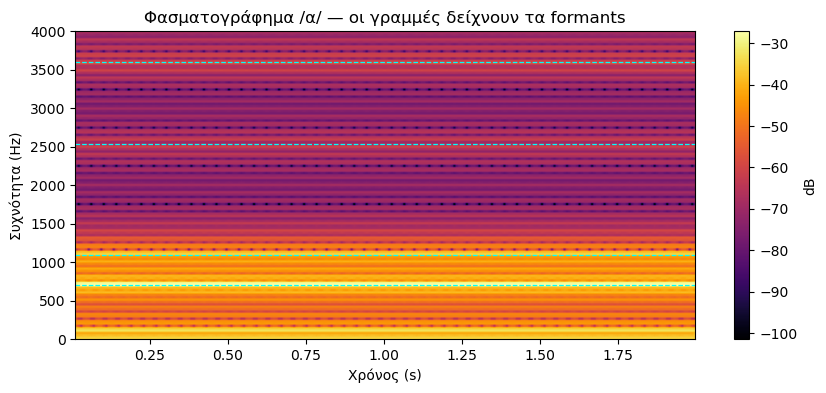

In [ ]:
plt.figure(figsize=(10, 4))
F_a = [700, 1100, 2530, 3600]
plt.specgram(speech, NFFT=256, Fs=fs, noverlap=192, cmap='inferno')
for F in F_a:
    plt.axhline(F, color='cyan', ls='--', lw=0.9)
plt.ylim(0, 4000)
plt.xlabel('Χρόνος (s)')
plt.ylabel('Συχνότητα (Hz)')
plt.title('Φασματογράφημα /α/ — οι γραμμές δείχνουν τα formants')
plt.colorbar(label='dB')
plt.show()

(λ') **Σύνθεση και των /ε/ και /ο/**

Παραπάνω χτίσαμε μόνο το φώνημα /α/. Με τη βοηθητική συνάρτηση`formant_filter` παρακάτω (η οποία ουσιαστικά "μαζεύει" τα παραπάνω σε μια θέση) η σύνθεση των άλλων φωνηέντων ανάγεται σε αλλαγή του πίνακα formant. 

Ο παρακάτω πίνακας σας δίνει τυπικές μέσες τιμές (Hz) για τα /ε/, /ο/:

| Φώνημα | $F_1$ | $F_2$ | $F_3$ | $F_4$ |
|:------:|:----:|:----:|:----:|:----:|
| /α/ | 700 | 1100 | 2530 | 3600 |
| /ε/ | 530 | 1840 | 2480 | 3600 |
| /ο/ | 450 |  800 | 2540 | 3400 |

Παρατηρήστε το $F_2$: χαμηλό για το /ο/ (στρογγυλό), ψηλό για το /ε/ (μπροστινό). Αυτό ξεχωρίζει τα φωνήεντα — και θα το αξιοποιήσουμε στη σύνθεση ομιλίας σε επόμενη άσκηση αυτού του Κεφαλαίου.

In [ ]:
def formant_filter(formants, bandwidths, fs=fs):
    """Παρονομαστής του all-pole V(z) από λίστες συχνοτήτων formant (Hz) και ευρών ζώνης (Hz)."""
    den = np.array([1.0])
    for F, B in zip(formants, bandwidths):
        r = np.exp(-np.pi * B / fs)      # μέτρο πόλου από το εύρος ζώνης
        theta = 2 * np.pi * F / fs       # γωνία πόλου από τη συχνότητα
        den = np.convolve(den, [1.0, -2 * r * np.cos(theta), r * r])

    return den

def synth_vowel(formants, bandwidths, f0=100, dur=1.5):
    """Πλήρης αλυσίδα: e[n] -> Rosenberg -> V(z) -> χείλη R(z) -> κανονικοποίηση."""
    e = genpulse(f0, dur)
    g = rosenmodel(round(0.6 * fs / f0), round(0.3 * fs / f0), f0).reshape(-1)
    gp = sig.convolve(e, g)
    den = formant_filter(formants, bandwidths)
    y = sig.lfilter([1.0], den, gp)
    s = sig.lfilter([1, -0.95], [1], y)

    return s / np.max(np.abs(s))

F_a = [700, 1100, 2530, 3600]
B_a = [80, 90, 120, 150]
B_common = [70, 100, 120, 150]
speech_e = synth_vowel([530, 1840, 2480, 3600], B_common)
speech_o = synth_vowel([450,  800, 2540, 3400], B_common)

print('/ε/'); display(Audio(speech_e, rate=fs))
print('/ο/'); display(Audio(speech_o, rate=fs))

/ε/


/ο/


(ιβ') Αν τα κάνατε όλα σωστά, το αποτέλεσμά σας θα ακούγεται κάπως ''ρομποτικό''. Προσπαθήστε να βάλετε λίγη ``φυσικότητα'' εισάγοντας λίγη ποσότητα τυχαίου θορύβου μικρής ισχύος στο διάνυσμα $\mathrm{e}$, πριν αυτό περάσει από τα υπόλοιπα φίλτρα, με τις εντολές

In [37]:
P = 0.0125
e = e + P * np.random.randn(1, len(e))


Ακούστε ξανά το σήμα. Πειραματιστείτε **αν θέλετε** για μια τιμή του $\mathrm{P}$ που να δίνει μια λίγο καλύτερη φυσικότητα στο σήμα σας, χωρίς να το κάνει πολύ θορυβώδες - μην περιμένετε θαύματα, θα εξακολουθεί να ακούγεται αρκετά ''στάσιμο''. Τέλος, παίξτε αν θέλετε με τις τιμές των $N_1,N_2$ που αφορούν το μοντέλο Rosenberg.


---
---